<a href="https://colab.research.google.com/github/mrrana51940/ML-projects/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [512]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import pandas as pd
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

### Load the train and test **dataset**

In [513]:
train_df=pd.read_csv('/content/titanic_train.csv')
test_df=pd.read_csv('/content/titanic_test.csv')
print(train_df.head(10))
print(train_df.shape)
print(' ')
print(test_df.head(10))
print(test_df.shape)

   PassengerId  Survived  Pclass                                               Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1         0       3                            Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3         1       3                             Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000  C123        S
4            5         0       3                           Allen, Mr. William Henry    male  35.0      0      0            373450   8.0500   NaN        S
5            6         0       3                                   Moran, Mr

In [514]:
train_id=train_df['PassengerId']
test_id=test_df['PassengerId']

In [515]:
survived=train_df['Survived']
train_df=train_df.drop(['Survived'], axis=1)
print(train_df.head(10))

   PassengerId  Pclass                                               Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1       3                            Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2       1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3       3                             Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000  C123        S
4            5       3                           Allen, Mr. William Henry    male  35.0      0      0            373450   8.0500   NaN        S
5            6       3                                   Moran, Mr. James    male   NaN      0      0            330877   8.4583   NaN  

### combine train and **test**

In [516]:
combine_df=pd.concat([train_df,test_df]).reset_index(drop=True)
print(combine_df.head(10))
print(combine_df.shape)

   PassengerId  Pclass                                               Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1       3                            Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2       1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3       3                             Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000  C123        S
4            5       3                           Allen, Mr. William Henry    male  35.0      0      0            373450   8.0500   NaN        S
5            6       3                                   Moran, Mr. James    male   NaN      0      0            330877   8.4583   NaN  

## Null values

In [517]:
combine_df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,263
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,1014


## **Age null values handling**

Text(0.5, 1.0, 'Various ages')

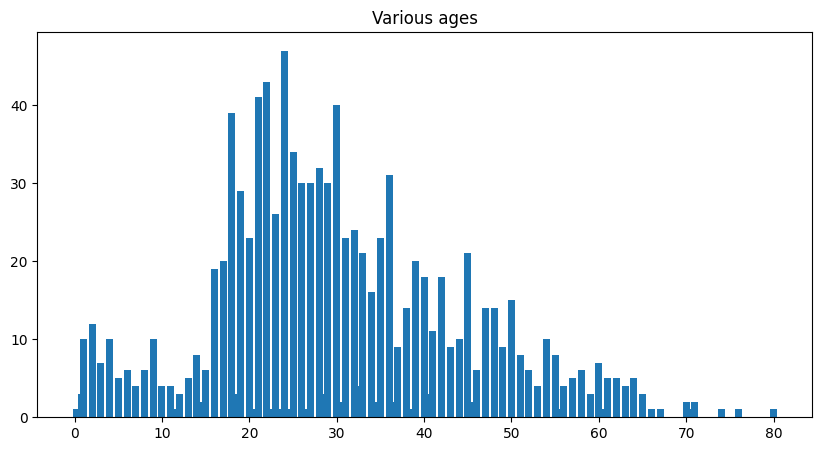

In [518]:
y=combine_df['Age'].value_counts()
x=y.index.values
plt.figure(figsize=(10,5))
plt.bar(x,y)
plt.title('Various ages')

Text(0.5, 1.0, 'Ages inp class 3')

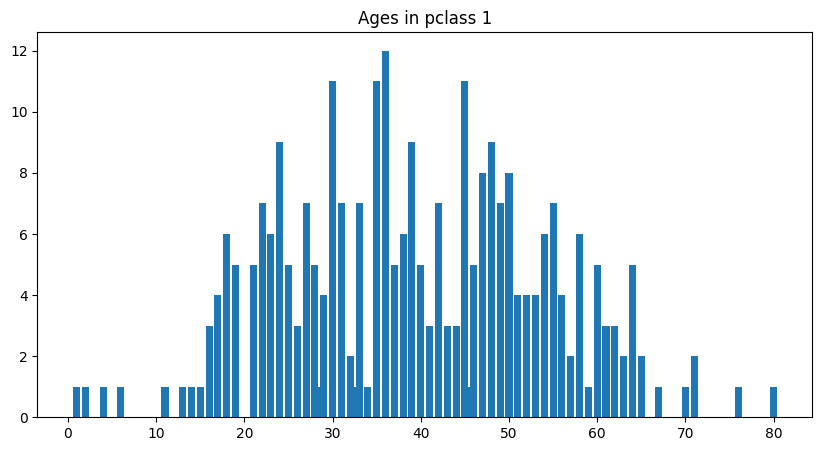

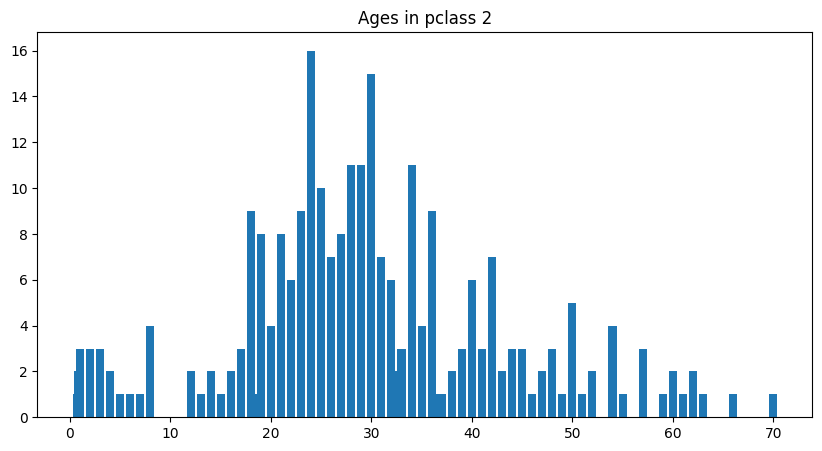

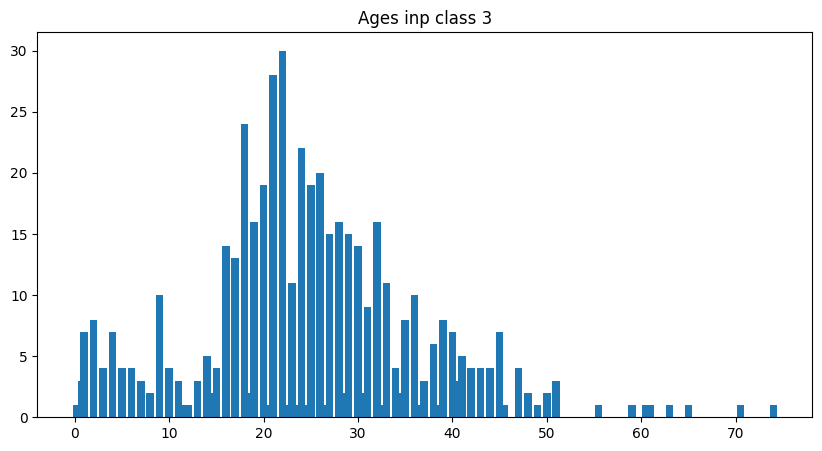

In [519]:
y_1=combine_df[combine_df['Pclass'] == 1]['Age'].value_counts()
x_1=y_1.index.values
plt.figure(figsize=(10,5))
plt.bar(x_1,y_1)
plt.title('Ages in pclass 1')


y_2=combine_df[combine_df['Pclass'] == 2]['Age'].value_counts()
x_2 =y_2.index.values
plt.figure(figsize=(10,5))
plt.bar(x_2,y_2)
plt.title('Ages in pclass 2')


y_3=combine_df[combine_df['Pclass'] == 3]['Age'].value_counts()
x_3 =y_3.index.values
plt.figure(figsize=(10,5))
plt.bar(x_3,y_3)
plt.title('Ages inp class 3')

In [520]:
age_p1_mediuan=combine_df[combine_df['Pclass'] == 1]['Age'].median()
age_p2_mediuan=combine_df[combine_df['Pclass'] == 2]['Age'].median()
age_p3_mediuan=combine_df[combine_df['Pclass'] == 3]['Age'].median()
print(age_p1_mediuan)
print(age_p2_mediuan)
print(age_p3_mediuan)

39.0
29.0
24.0


In [521]:
combine_df.loc[(combine_df['Age'].isnull()) & (combine_df['Pclass']==1),'Age']=age_p1_mediuan
combine_df.loc[(combine_df['Age'].isnull()) & (combine_df['Pclass']==2),'Age']=age_p2_mediuan
combine_df.loc[(combine_df['Age'].isnull()) & (combine_df['Pclass']==3),'Age']=age_p3_mediuan
combine_df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,1014


In [522]:
combine_df.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,3,"Moran, Mr. James",male,24.0,0,0,330877,8.4583,NaN,Q
6,7,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## Fare Null values **handling**

In [523]:
print(combine_df[combine_df['Fare'].isnull()])

      PassengerId  Pclass                Name   Sex   Age  SibSp  Parch Ticket  Fare Cabin Embarked
1043         1044       3  Storey, Mr. Thomas  male  60.5      0      0   3701   NaN   NaN        S


In [524]:
fare_n=combine_df.loc[(combine_df['Pclass']==3) & (combine_df['Embarked']=='S'), 'Fare'].median()
print(fare_n)

8.05


In [525]:
combine_df.loc[(combine_df['Fare'].isnull()), 'Fare'] = fare_n
print(combine_df.isnull().sum())

PassengerId       0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          2
dtype: int64


## Embarked Missing values **Handling**

In [526]:
print(combine_df[combine_df['Embarked'].isnull()])

     PassengerId  Pclass                                       Name     Sex   Age  SibSp  Parch  Ticket  Fare Cabin Embarked
61            62       1                        Icard, Miss. Amelie  female  38.0      0      0  113572  80.0   B28      NaN
829          830       1  Stone, Mrs. George Nelson (Martha Evelyn)  female  62.0      0      0  113572  80.0   B28      NaN


In [527]:
embarked_n=combine_df.loc[(combine_df['Pclass']==1) & (combine_df['Fare']>=75) & (combine_df['Fare']<=85), 'Embarked']
print(embarked_n.shape)
embarked_n.value_counts()

(45,)


,count
Embarked,
C,25
S,18


In [528]:
combine_df.loc[combine_df['Embarked'].isnull(),'Embarked']='C'
combine_df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,1014


## Cabin missing values **handling**

In [529]:

combine_df.loc[combine_df['Cabin'].isnull(),'Cabin']='M'
combine_df['Cabin']=combine_df['Cabin'].str[0]
combine_df['Cabin'].value_counts()


,count
Cabin,
M,1014
C,94
B,65
D,46
E,41
A,22
F,21
G,5
T,1


In [530]:
combine_df.loc[combine_df['Cabin']=='T','Cabin']='M'
combine_df['Cabin'].value_counts()

,count
Cabin,
M,1015
C,94
B,65
D,46
E,41
A,22
F,21
G,5


In [531]:
combine_df.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S
5,6,3,"Moran, Mr. James",male,24.0,0,0,330877,8.4583,M,Q
6,7,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E,S
7,8,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,M,S
8,9,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,M,S
9,10,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,M,C


In [532]:
combine_df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0


## **Feature engineering**

In [533]:
combine_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S


In [534]:
combine_df.nunique()

,0
PassengerId,1309
Pclass,3
Name,1307
Sex,2
Age,98
SibSp,7
Parch,8
Ticket,929
Fare,281
Cabin,8


## **name feature**

In [535]:
last_name=[]
title=[]
first_name=[]
#Braund, Mr. Owen Harris
for name in combine_df['Name']:
  if ',' not in name:
    last_name.append(' ')
  else:
    last,name=name.split(',',1)
    last_name.append(last)

  if '.' not in name:
    title.append(' ')
  else:
    title_1,name=name.split('.',1)
    title.append(title_1)
    first_name.append(name)

combine_df['Title']=title
combine_df.head()
title = pd.Series(title)
print(title.value_counts())

Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Major             2
Mlle              2
Ms                2
Mme               1
Don               1
Sir               1
Lady              1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: count, dtype: int64


In [536]:
combine_df['Title']=combine_df['Title'].replace(['Mlle','Ms'],' Miss')
combine_df['Title']=combine_df['Title'].replace(['Mme'],'Mrs')
rare_titles=combine_df['Title'].value_counts()[combine_df['Title'].value_counts()<5].index
combine_df['Title']=combine_df['Title'].replace(rare_titles,'Rare')
print(combine_df['Title'].value_counts())

Title
 Mr        757
 Miss      260
 Mrs       197
 Master     61
Rare        18
 Rev         8
 Dr          8
Name: count, dtype: int64


In [537]:

combine_df.nunique()

,0
PassengerId,1309
Pclass,3
Name,1307
Sex,2
Age,98
SibSp,7
Parch,8
Ticket,929
Fare,281
Cabin,8


## Age feature

In [538]:
print(combine_df['Age'].min(),combine_df['Age'].max())

0.17 80.0


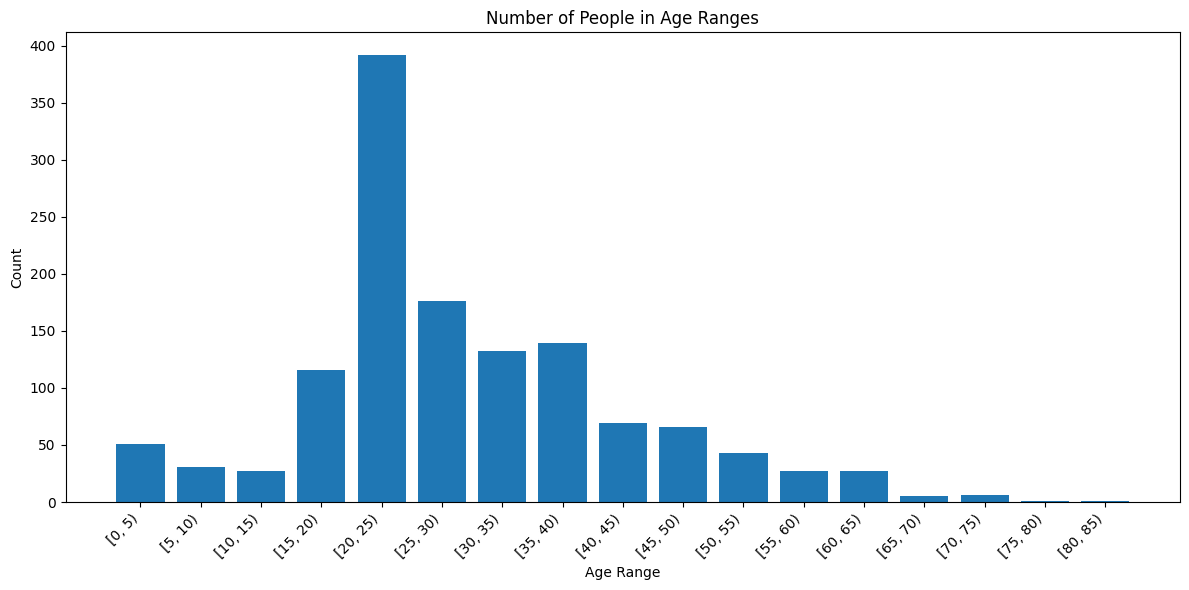

In [539]:

bins=range(0,int(combine_df['Age'].max())+6, 5)

age_bins = pd.cut(combine_df['Age'], bins=bins, right=False)
age_bin_counts = age_bins.value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.bar(age_bin_counts.index.astype(str), age_bin_counts.values)
plt.title('Number of People in Age Ranges')
plt.xlabel('Age Range')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [540]:
combine_df['Age_Bin']=age_bins
combine_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_Bin
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,"[20, 25)"
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,"[35, 40)"
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Miss,"[25, 30)"
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,"[35, 40)"
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,"[35, 40)"


In [541]:
combine_df.nunique()

,0
PassengerId,1309
Pclass,3
Name,1307
Sex,2
Age,98
SibSp,7
Parch,8
Ticket,929
Fare,281
Cabin,8


## siblings feature

In [542]:
combine_df['Total_Family']=combine_df['SibSp']+combine_df['Parch']+1
combine_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_Bin,Total_Family
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,"[20, 25)",2
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,"[35, 40)",2
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Miss,"[25, 30)",1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,"[35, 40)",2
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,"[35, 40)",1


## **Ticket Feature**

In [543]:
combine_df['Ticket'].value_counts()

,count
Ticket,
CA. 2343,11
1601,8
CA 2144,8
347082,7
S.O.C. 14879,7
...,...
A.5. 3236,1
347086,1
365237,1


In [544]:
combine_df.loc[combine_df['Ticket']=='CA. 2343']

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_Bin,Total_Family
159,160,3,"Sage, Master. Thomas Henry",male,24.0,8,2,CA. 2343,69.55,M,S,Master,"[20, 25)",11
180,181,3,"Sage, Miss. Constance Gladys",female,24.0,8,2,CA. 2343,69.55,M,S,Miss,"[20, 25)",11
201,202,3,"Sage, Mr. Frederick",male,24.0,8,2,CA. 2343,69.55,M,S,Mr,"[20, 25)",11
324,325,3,"Sage, Mr. George John Jr",male,24.0,8,2,CA. 2343,69.55,M,S,Mr,"[20, 25)",11
792,793,3,"Sage, Miss. Stella Anna",female,24.0,8,2,CA. 2343,69.55,M,S,Miss,"[20, 25)",11
846,847,3,"Sage, Mr. Douglas Bullen",male,24.0,8,2,CA. 2343,69.55,M,S,Mr,"[20, 25)",11
863,864,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,24.0,8,2,CA. 2343,69.55,M,S,Miss,"[20, 25)",11
1079,1080,3,"Sage, Miss. Ada",female,24.0,8,2,CA. 2343,69.55,M,S,Miss,"[20, 25)",11
1233,1234,3,"Sage, Mr. John George",male,24.0,1,9,CA. 2343,69.55,M,S,Mr,"[20, 25)",11
1251,1252,3,"Sage, Master. William Henry",male,14.5,8,2,CA. 2343,69.55,M,S,Master,"[10, 15)",11


In [545]:
ticket_counts=combine_df['Ticket'].value_counts()
combine_df['Ticket_count']=combine_df['Ticket'].map(ticket_counts)
print(combine_df.head(10))

   PassengerId  Pclass                                               Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked    Title   Age_Bin  Total_Family  Ticket_count
0            1       3                            Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500     M        S       Mr  [20, 25)             2             1
1            2       1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1      0          PC 17599  71.2833     C        C      Mrs  [35, 40)             2             2
2            3       3                             Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250     M        S     Miss  [25, 30)             1             1
3            4       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000     C        S      Mrs  [35, 40)             2             2
4            5       3                       

## **Fare Feature**

In [546]:
combine_df['Fare_per_ticket']=combine_df['Fare']/combine_df['Ticket_count']
print(combine_df.head())

   PassengerId  Pclass                                               Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked  Title   Age_Bin  Total_Family  Ticket_count  Fare_per_ticket
0            1       3                            Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500     M        S     Mr  [20, 25)             2             1          7.25000
1            2       1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1      0          PC 17599  71.2833     C        C    Mrs  [35, 40)             2             2         35.64165
2            3       3                             Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250     M        S   Miss  [25, 30)             1             1          7.92500
3            4       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000     C        S    Mrs  [35, 40)             2  

## **Fare Bin**

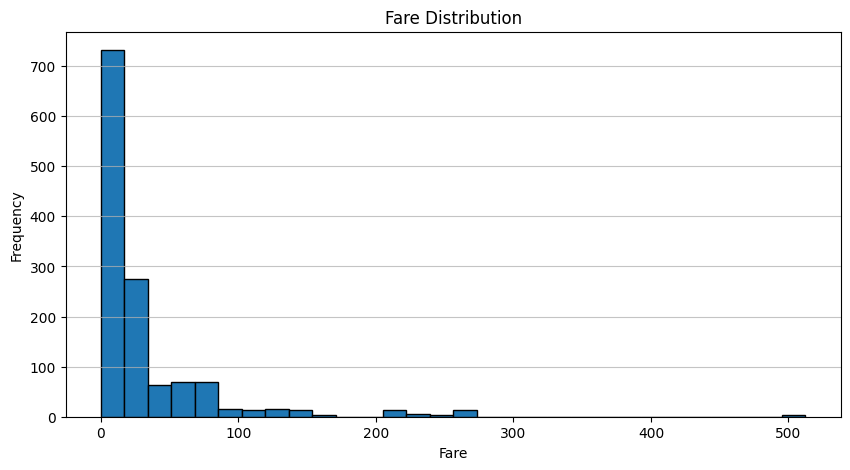

In [547]:
plt.figure(figsize=(10,5))

plt.hist(combine_df['Fare'], bins=30, edgecolor='black')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.show()

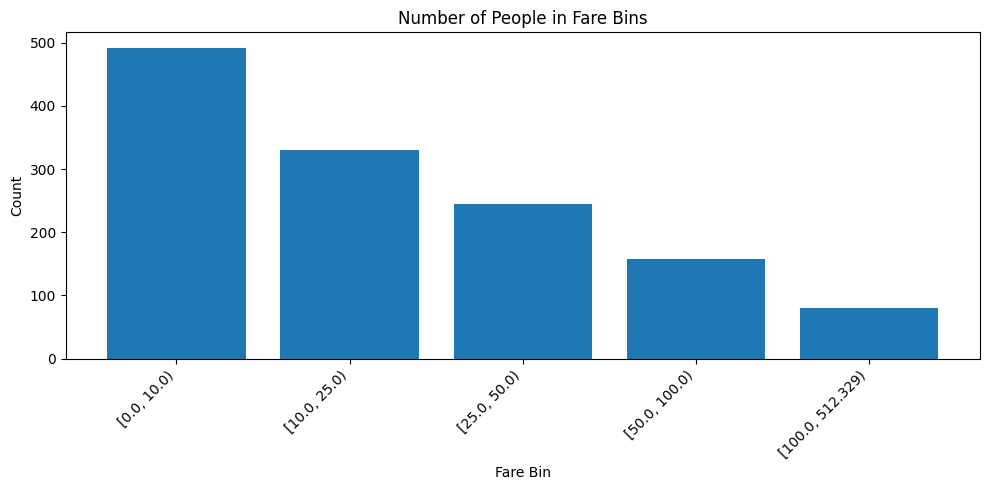

In [548]:

plt.figure(figsize=(10,5))
plt.bar(fare_bin_counts.index.astype(str),fare_bin_counts.values)
plt.title('Number of People in Fare Bins')
plt.xlabel('Fare Bin')
plt.ylabel('Count')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

In [549]:
print(combine_df['Fare'].min(),combine_df['Fare'].max())
bins=[0,10,25,50,100,513]

combine_df['FareBin'] = pd.cut(combine_df['Fare_per_ticket'], bins=bins)

display(combine_df.head())
print(combine_df['FareBin'].value_counts())

0.0 512.3292


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_Bin,Total_Family,Ticket_count,Fare_per_ticket,FareBin
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,"[20, 25)",2,1,7.25000,"(0, 10]"
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,"[35, 40)",2,2,35.64165,"(25, 50]"
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Miss,"[25, 30)",1,1,7.92500,"(0, 10]"
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,"[35, 40)",2,2,26.55000,"(25, 50]"
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,"[35, 40)",1,1,8.05000,"(0, 10]"


FareBin
(0, 10]       746
(25, 50]      279
(10, 25]      243
(50, 100]      20
(100, 513]      4
Name: count, dtype: int64


In [550]:
combine_df.nunique()

,0
PassengerId,1309
Pclass,3
Name,1307
Sex,2
Age,98
SibSp,7
Parch,8
Ticket,929
Fare,281
Cabin,8


## Column **Dropping**

In [551]:
combine_df.drop(['Name','Age','Ticket','Fare','Fare_per_ticket','SibSp','Parch'],axis=1,inplace=True)
combine_df.head()

,PassengerId,Pclass,Sex,Cabin,Embarked,Title,Age_Bin,Total_Family,Ticket_count,FareBin
0,1,3,male,M,S,Mr,"[20, 25)",2,1,"(0, 10]"
1,2,1,female,C,C,Mrs,"[35, 40)",2,2,"(25, 50]"
2,3,3,female,M,S,Miss,"[25, 30)",1,1,"(0, 10]"
3,4,1,female,C,S,Mrs,"[35, 40)",2,2,"(25, 50]"
4,5,3,male,M,S,Mr,"[35, 40)",1,1,"(0, 10]"


In [552]:
combine_df.nunique()

,0
PassengerId,1309
Pclass,3
Sex,2
Cabin,8
Embarked,3
Title,7
Age_Bin,17
Total_Family,9
Ticket_count,9
FareBin,5


In [553]:
print(combine_df)

      PassengerId  Pclass     Sex Cabin Embarked    Title   Age_Bin  Total_Family  Ticket_count   FareBin
0               1       3    male     M        S       Mr  [20, 25)             2             1   (0, 10]
1               2       1  female     C        C      Mrs  [35, 40)             2             2  (25, 50]
2               3       3  female     M        S     Miss  [25, 30)             1             1   (0, 10]
3               4       1  female     C        S      Mrs  [35, 40)             2             2  (25, 50]
4               5       3    male     M        S       Mr  [35, 40)             1             1   (0, 10]
...           ...     ...     ...   ...      ...      ...       ...           ...           ...       ...
1304         1305       3    male     M        S       Mr  [20, 25)             1             1   (0, 10]
1305         1306       1  female     C        C     Rare  [35, 40)             1             3  (25, 50]
1306         1307       3    male     M       

## Model **Training**

In [554]:
combine_df.set_index('PassengerId',inplace=True)
combine_df.head()

,Pclass,Sex,Cabin,Embarked,Title,Age_Bin,Total_Family,Ticket_count,FareBin
PassengerId,,,,,,,,,
1,3,male,M,S,Mr,"[20, 25)",2,1,"(0, 10]"
2,1,female,C,C,Mrs,"[35, 40)",2,2,"(25, 50]"
3,3,female,M,S,Miss,"[25, 30)",1,1,"(0, 10]"
4,1,female,C,S,Mrs,"[35, 40)",2,2,"(25, 50]"
5,3,male,M,S,Mr,"[35, 40)",1,1,"(0, 10]"


In [555]:
from sklearn.preprocessing import LabelEncoder
label_df=combine_df.copy()
label_df=label_df.astype(str)
label_df=label_df.apply(LabelEncoder().fit_transform)
print(label_df)


             Pclass  Sex  Cabin  Embarked  Title  Age_Bin  Total_Family  Ticket_count  FareBin
PassengerId                                                                                   
1                 2    1      7         2      3        3             2             0        0
2                 0    0      2         0      4        6             2             2        3
3                 2    0      7         2      2        4             0             0        0
4                 0    0      2         2      4        6             2             2        3
5                 2    1      7         2      3        6             0             0        0
...             ...  ...    ...       ...    ...      ...           ...           ...      ...
1305              2    1      7         2      3        3             0             0        0
1306              0    0      2         0      6        6             0             3        3
1307              2    1      7         2      3  

In [556]:
onehot_df=label_df.copy()
onehot_df=pd.get_dummies(onehot_df,columns=['Sex','Cabin','Embarked','Title'], dtype=int)
print(onehot_df)

             Pclass  Age_Bin  Total_Family  Ticket_count  FareBin  Sex_0  Sex_1  Cabin_0  Cabin_1  Cabin_2  Cabin_3  Cabin_4  Cabin_5  Cabin_6  Cabin_7  Embarked_0  Embarked_1  Embarked_2  Title_0  Title_1  Title_2  Title_3  Title_4  Title_5  Title_6
PassengerId                                                                                                                                                                                                                                               
1                 2        3             2             0        0      0      1        0        0        0        0        0        0        0        1           0           0           1        0        0        0        1        0        0        0
2                 0        6             2             2        3      1      0        0        0        1        0        0        0        0        0           1           0           0        0        0        0        0        1        0      

In [557]:
X=onehot_df.loc[train_id].values
Y=survived.values
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(X)
X_scaled=scaler.fit_transform(X)

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X_scaled,Y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(712, 25)
(179, 25)


# Random Forest *Classifier*

In [558]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rfc=RandomForestClassifier(random_state=42)
rfc.fit(X_train,Y_train)
Y_pred=rfc.predict(X_test)
print(accuracy_score(Y_test,Y_pred))

0.8156424581005587


## Randomized search cv

In [560]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'criterion': ['gini', 'entropy'],
    'n_estimators':randint(100, 1000),
    'max_samples':[0.5, 0.8, 1.0],
    'max_features':['sqrt', 'log2', None],
    'max_depth': randint(1, 20),
    'min_samples_split':randint(2, 20),
    'min_samples_leaf':randint(1, 20),
    'bootstrap':[True]
}

rfc=RandomForestClassifier(random_state=42)
random_search=RandomizedSearchCV(
    estimator=rfc,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring='accuracy',
    random_state=42,
)


random_search.fit(X_train,Y_train)
print('Best param=',random_search.best_params_)
print(random_search.best_score_)

train_pred=random_search.predict(X_train)
print('Train acc=',random_search.score(X_train,Y_train))
test_pred=random_search.predict(X_test)
print('Test acc=',accuracy_score(Y_test,test_pred))


Best param= {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 17, 'max_features': 'sqrt', 'max_samples': 1.0, 'min_samples_leaf': 5, 'min_samples_split': 7, 'n_estimators': 870}
0.8356249384418397
Train acc= 0.851123595505618
Test acc= 0.8212290502793296


In [561]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'criterion': ['gini', 'entropy'],
    'n_estimators':randint(100, 1000),
    'max_samples':[0.5, 0.8, 1.0],
    'max_features':['sqrt', 'log2', None],
    'max_depth': randint(1, 20),
    'min_samples_split':randint(2, 20),
    'min_samples_leaf':randint(1, 20),
    'bootstrap':[True,False]
}

rfc=RandomForestClassifier(random_state=42)
random_search=RandomizedSearchCV(
    estimator=rfc,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring='accuracy',
    random_state=42,
)


random_search.fit(X_train,Y_train)
print('Best param=',random_search.best_params_)
print(random_search.best_score_)

train_pred=random_search.predict(X_train)
print('Train acc=',random_search.score(X_train,Y_train))
test_pred=random_search.predict(X_test)
print('Test acc=',accuracy_score(Y_test,test_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
225 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
225 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py", line 431, in fit
    raise ValueError(
ValueErr

Best param= {'bootstrap': True, 'criterion': 'gini', 'max_depth': 16, 'max_features': 'sqrt', 'max_samples': 1.0, 'min_samples_leaf': 5, 'min_samples_split': 4, 'n_estimators': 175}
0.832817886339013
Train acc= 0.8539325842696629
Test acc= 0.8324022346368715


In [562]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'criterion': ['gini', 'entropy'],
    'n_estimators':randint(100, 1000),
    'max_features':['sqrt', 'log2', None],
    'max_depth': randint(1, 20),
    'min_samples_split':randint(2, 20),
    'min_samples_leaf':randint(1, 20),
    'bootstrap':[True]
}

rfc=RandomForestClassifier(random_state=42)
random_search=RandomizedSearchCV(
    estimator=rfc,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring='accuracy',
    random_state=42,
)


random_search.fit(X_train,Y_train)
print('Best param=',random_search.best_params_)
print(random_search.best_score_)

train_pred=random_search.predict(X_train)
print('Train acc=',random_search.score(X_train,Y_train))
test_pred=random_search.predict(X_test)
print('Test acc=',accuracy_score(Y_test,test_pred))


Best param= {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 13, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 17, 'n_estimators': 288}
0.8342361863488623
Train acc= 0.8707865168539326
Test acc= 0.8324022346368715
